# Revisar piezas originales -- filtro automático + revisión manual

Combina las dos cosas:
1. Un escaneo automático marca las piezas "sospechosas" (desconectadas o
   con forma degenerada). El resultado se guarda en Drive, así que este
   paso solo hace falta ejecutarlo una vez -- si lo relanzas, usa la
   caché en vez de volver a escanear las 2.367 mallas.
2. Solo esas sospechosas pasan por la revisión manual una a una (mucho
   menos que el total). El resto se da por bueno automáticamente.
3. Al final, copia a una carpeta nueva todo lo que decidiste conservar
   (más lo que nunca fue marcado como sospechoso) -- sin tocar el origen.

**Orden de uso:**
1. Celda 1 -- montar Drive
2. Celda 2 -- configurar rutas
3. Celda 3 -- escaneo automático (una vez; usa caché si ya existe)
4. Celda 4 -- funciones para la revisión manual
5. Celda 5 -- ver progreso
6. Celda 6 -- revisión manual (solo de las sospechosas)
7. Celda 7 -- copiar el resultado final a `depuracion_previa_a_roturas`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', 'plyfile', 'scikit-learn', '--quiet'])
print("Listo.")

In [ ]:
from pathlib import Path

DRIVE = '/content/drive/MyDrive'
RUTA_SHAPENET       = f'{DRIVE}/Datos_E2_E3/General/Shapenet_limpias'
RUTA_OBJAVERSE      = f'{DRIVE}/Datos_E2_E3/General/Objaverse_limpias'
RUTA_CSV_SOSPECHOSOS = f'{DRIVE}/Datos_E2_E3/General/originales_sospechosos.csv'
RUTA_PROGRESO       = f'{DRIVE}/Datos_E2_E3/General/revision_manual_progreso.json'
RUTA_DEPURADA       = f'{DRIVE}/Datos_E2_E3/General/depuracion_previa_a_roturas'

for nombre, ruta in [('shapenet', RUTA_SHAPENET), ('objaverse', RUTA_OBJAVERSE)]:
    p = Path(ruta)
    if p.exists():
        n = len(list(p.rglob('*.ply')))
        print(f"  OK  {nombre}: {n} .ply")
    else:
        print(f"  ERROR  {nombre}: {ruta} no encontrado")

### Escaneo automático (una sola vez -- usa caché si ya existe)
Detecta dos tipos de problema, igual que antes:
- **desconectada**: la malla se separa en 2+ trozos sin relación entre sí
  (eps de conexión ADAPTATIVO por objeto, para no penalizar asas finas)
- **degenerada**: forma casi lineal/plana, o con muy pocos vértices únicos

Si ya existe `originales_sospechosos.csv` en Drive, esta celda lo carga
directamente en vez de volver a escanear las 2.367 mallas -- así que
puedes relanzarla sin miedo, tarda segundos si ya está hecho. Para forzar
un reescaneo desde cero, borra ese CSV de Drive primero.

In [ ]:
import csv
import numpy as np
from plyfile import PlyData
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

N_PUNTOS = 2048
FACTOR_EPS = 4.0
K_VECINOS = 5
MIN_MUESTRAS = 10
RATIO_ANISOTROPIA_MIN = 0.02
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

def cargar_puntos(ruta):
    try:
        plydata = PlyData.read(str(ruta))
        v = plydata['vertex']
        pts = np.column_stack([
            np.asarray(v['x'], dtype=np.float32),
            np.asarray(v['y'], dtype=np.float32),
            np.asarray(v['z'], dtype=np.float32),
        ])
        return pts if len(pts) >= 100 else None
    except Exception:
        return None

def normalizar(pts):
    pts = pts - pts.mean(axis=0)
    r = np.linalg.norm(pts, axis=1).max()
    return pts / r if r > 0 else pts

def submuestrear(pts, n, rng):
    if len(pts) >= n:
        idx = rng.choice(len(pts), n, replace=False)
    else:
        idx = rng.choice(len(pts), n, replace=True)
    return pts[idx].astype(np.float32)

archivos_shapenet = sorted(Path(RUTA_SHAPENET).rglob('*.ply'))
archivos_objaverse = sorted(Path(RUTA_OBJAVERSE).rglob('*.ply'))
archivos = [(r, 'shapenet') for r in archivos_shapenet] + [(r, 'objaverse') for r in archivos_objaverse]
print(f"Total de mallas: {len(archivos)} ({len(archivos_shapenet)} shapenet, {len(archivos_objaverse)} objaverse)")

if Path(RUTA_CSV_SOSPECHOSOS).exists():
    print(f"\nUsando cache: {RUTA_CSV_SOSPECHOSOS}")
    sospechosos = []
    with open(RUTA_CSV_SOSPECHOSOS, 'r', encoding='utf-8') as f:
        r = csv.DictReader(f)
        for fila in r:
            sospechosos.append((fila['id'], fila['motivo'], fila['ruta'], fila['origen']))
    print(f"Sospechosos cargados: {len(sospechosos)}")
else:
    print("\nNo hay cache -- escaneando desde cero (puede tardar varios minutos)...")
    sospechosos = []
    for i, (ruta, origen) in enumerate(archivos):
        pts_raw = cargar_puntos(ruta)
        if pts_raw is None:
            sospechosos.append((ruta.stem, "ilegible", str(ruta), origen))
            continue

        pts_norm = normalizar(pts_raw)
        pts = submuestrear(pts_norm, N_PUNTOS, rng)

        n_unicos = len(np.unique(pts, axis=0))
        if n_unicos < 500:
            sospechosos.append((ruta.stem, f"pocos_puntos_unicos ({n_unicos}/{N_PUNTOS})", str(ruta), origen))
            continue

        nn = NearestNeighbors(n_neighbors=K_VECINOS + 1).fit(pts)
        dist, _ = nn.kneighbors(pts)
        dist_validas = dist[:, 1:]
        dist_validas = dist_validas[dist_validas > 0]
        if len(dist_validas) == 0:
            sospechosos.append((ruta.stem, "sin_distancias_validas", str(ruta), origen))
            continue
        eps_adaptativo = FACTOR_EPS * np.median(dist_validas)

        etiquetas = DBSCAN(eps=eps_adaptativo, min_samples=MIN_MUESTRAS).fit_predict(pts)
        etiquetas_validas = etiquetas[etiquetas >= 0]
        if len(etiquetas_validas) == 0:
            n_clusters_grandes = 0
        else:
            _, conteos = np.unique(etiquetas_validas, return_counts=True)
            n_clusters_grandes = np.sum(conteos >= 0.05 * len(pts))

        motivo = None
        if n_clusters_grandes >= 2:
            motivo = f"desconectada ({n_clusters_grandes} clusters)"
        else:
            cov = np.cov((pts - pts.mean(axis=0)).T)
            vals = np.linalg.eigvalsh(cov)
            if vals[-1] > 0:
                ratio = vals[0] / vals[-1]
                if ratio < RATIO_ANISOTROPIA_MIN:
                    motivo = f"degenerada (ratio PCA={ratio:.4f})"

        if motivo:
            sospechosos.append((ruta.stem, motivo, str(ruta), origen))

        if (i + 1) % 300 == 0:
            print(f"  {i+1}/{len(archivos)} revisados, {len(sospechosos)} sospechosos hasta ahora")

    with open(RUTA_CSV_SOSPECHOSOS, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(["id", "motivo", "ruta", "origen"])
        w.writerows(sospechosos)
    print(f"\nEscaneo terminado. Guardado en: {RUTA_CSV_SOSPECHOSOS}")

print(f"\nTotal sospechosos: {len(sospechosos)} de {len(archivos)} ({100*len(sospechosos)/len(archivos):.1f}%)")

### Funciones para la revisión manual (ejecuta, no hace falta tocarla)

In [ ]:
import json
import matplotlib.pyplot as plt

def cargar_progreso():
    p = Path(RUTA_PROGRESO)
    if p.exists():
        with open(p, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}

def guardar_progreso(progreso):
    with open(RUTA_PROGRESO, 'w', encoding='utf-8') as f:
        json.dump(progreso, f, indent=1, ensure_ascii=False)

def mostrar_pieza(ruta_str, motivo):
    ruta = Path(ruta_str)
    pts_raw = cargar_puntos(ruta)
    if pts_raw is None:
        print(f"  [AVISO] No se pudo leer: {ruta}")
        return False
    pts = submuestrear(normalizar(pts_raw), N_PUNTOS, rng)
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=2, alpha=0.6, color='tab:red')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_title(f"{ruta.stem}\n{motivo}", fontsize=9)
    plt.show()
    return True

print("Funciones listas.")

### Ver progreso de la revisión

In [ ]:
progreso = cargar_progreso()
n_conservar = sum(1 for v in progreso.values() if v['decision'] == 'conservar')
n_descartar = sum(1 for v in progreso.values() if v['decision'] == 'descartar')

print(f"Sospechosas totales   : {len(sospechosos)}")
print(f"Revisadas hasta ahora : {len(progreso)}  (conservar: {n_conservar}, descartar: {n_descartar})")
print(f"Pendientes            : {len(sospechosos) - len(progreso)}")

### Revisión manual -- solo de las sospechosas
Para cada una: **c** conservar, **d** descartar, **s** saltar por ahora,
**q** salir (guarda todo y para). El progreso se guarda al momento tras
cada decisión, así que puedes cortar cuando quieras.

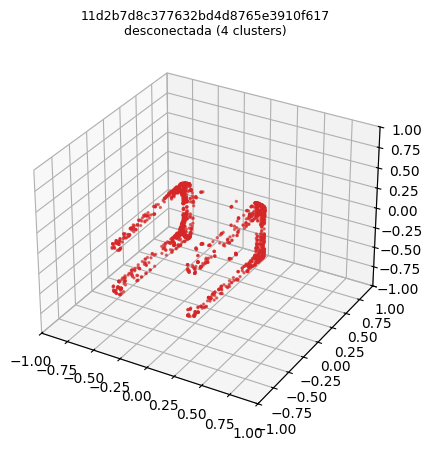

KeyboardInterrupt: Interrupted by user

In [6]:
progreso = cargar_progreso()
saltadas_esta_sesion = set()
salir = False

for id_, motivo, ruta_str, origen in sospechosos:
    if id_ in progreso or id_ in saltadas_esta_sesion:
        continue

    ok = mostrar_pieza(ruta_str, motivo)
    if not ok:
        progreso[id_] = {"decision": "descartar", "origen": origen, "motivo": "ilegible"}
        guardar_progreso(progreso)
        continue

    while True:
        resp = input(f"[{len(progreso)+1}/{len(sospechosos)}] {id_} -> (c)onservar / (d)escartar / (s)altar / (q)salir: ").strip().lower()
        if resp in ('c', 'd', 's', 'q'):
            break
        print("  Escribe c, d, s o q.")

    if resp == 'q':
        salir = True
        break
    elif resp == 's':
        saltadas_esta_sesion.add(id_)
        continue
    else:
        decision = 'conservar' if resp == 'c' else 'descartar'
        progreso[id_] = {"decision": decision, "origen": origen, "motivo": motivo}
        guardar_progreso(progreso)

print(f"\nProgreso guardado en: {RUTA_PROGRESO}")
print(f"Revisadas: {len(progreso)} de {len(sospechosos)} sospechosas")
if not salir and len(saltadas_esta_sesion) == 0 and len(progreso) == len(sospechosos):
    print("\n¡Has terminado de revisar todas las sospechosas!")

### Copiar el resultado final a `depuracion_previa_a_roturas`
Copia TODO excepto lo que hayas marcado explícitamente como "descartar".
Las piezas que nunca salieron como sospechosas se copian directamente (se
dan por buenas). Si quedan sospechosas sin revisar, se avisa y se dejan
fuera de la copia hasta que las decidas.

In [ ]:
import shutil

progreso = cargar_progreso()
ids_descartar = {id_ for id_, info in progreso.items() if info['decision'] == 'descartar'}
ids_sospechosos = {id_ for id_, _, _, _ in sospechosos}
ids_pendientes = ids_sospechosos - set(progreso.keys())

if ids_pendientes:
    print(f"[AVISO] Quedan {len(ids_pendientes)} sospechosas sin revisar -- se van a EXCLUIR de la copia por precaucion.")
    print("        Termina la revision (Celda 6) si quieres incluirlas.\n")

RUTA_DEPURADA_SHAPENET  = f'{RUTA_DEPURADA}/shapenet'
RUTA_DEPURADA_OBJAVERSE = f'{RUTA_DEPURADA}/objaverse'
Path(RUTA_DEPURADA_SHAPENET).mkdir(parents=True, exist_ok=True)
Path(RUTA_DEPURADA_OBJAVERSE).mkdir(parents=True, exist_ok=True)

copiados = 0
excluidos_descarte = 0
excluidos_pendiente = 0
ya_existian = 0

for ruta, origen in archivos:
    id_ = ruta.stem
    if id_ in ids_descartar:
        excluidos_descarte += 1
        continue
    if id_ in ids_pendientes:
        excluidos_pendiente += 1
        continue

    destino_dir = RUTA_DEPURADA_SHAPENET if origen == 'shapenet' else RUTA_DEPURADA_OBJAVERSE
    destino = Path(destino_dir) / ruta.name
    if destino.exists():
        ya_existian += 1
    else:
        shutil.copy2(ruta, destino)
    copiados += 1

print(f"Copiados a {RUTA_DEPURADA}: {copiados} (de ellos, {ya_existian} ya estaban copiados de antes)")
print(f"Excluidos por 'descartar' : {excluidos_descarte}")
print(f"Excluidos por pendientes  : {excluidos_pendiente}")
print(f"\nOrigen SIN TOCAR -- Shapenet_limpias y Objaverse_limpias siguen intactas.")